# CityTraffic Insight System — Model Training

## Goal

The goal of this project is to build machine learning models that can:

1. Predict **Travel Time Index** for a route.  
2. Predict **Traffic Congestion Level** (Low / Medium / High).  

These models will later be integrated into a **Streamlit dashboard** that provides:

- Route traffic prediction  
- Congestion risk analysis  
- Best travel time insights  
- Traffic analytics visualization  

---

## Dataset Description

The dataset consists of traffic data collected from multiple **areas and intersections across Bengaluru city**. It captures real-world urban traffic patterns using features such as:

- Traffic volume  
- Average speed  
- Road capacity utilization  
- Incident reports  
- Environmental impact  
- Public transport usage  
- Traffic signal compliance  
- Parking usage  
- Pedestrian and cyclist count  
- Weather conditions  

This data represents **traffic behavior across different regions of Bengaluru**, enabling area-level traffic intelligence and analysis.

---

## Models Used

### 1. Random Forest Regressor
- Predicts **Travel Time Index**  
- Helps estimate travel delays and route efficiency  

### 2. Random Forest Classifier
- Predicts **Traffic Congestion Level**  
- Classifies traffic into:
  - Low  
  - Medium  
  - High  

---

## Deployment

The trained models will be saved as `.pkl` files and integrated into the:

### 👉 CityTraffic Insight System Dashboard

This dashboard will enable:

- Real-time traffic estimation (data-driven)  
- Area-based congestion insights  
- Intelligent travel recommendations  
- Traffic pattern analysis  

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

import pickle

## Loading Dataset

The dataset is stored on Google Drive and contains traffic observations
from multiple intersections in Bengaluru.

We load the dataset using pandas.

In [2]:
url = "https://drive.google.com/uc?id=1AMBzflTbushZN3zzZL-pl390QCm3e5Qx"

df = pd.read_csv(url)

df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


## Dataset Information

We inspect the structure of the dataset including:

- Number of rows and columns
- Data types
- Missing values

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 no

Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                    0
Roadwork and Construction Activity    0
dtype: int64

## Feature Engineering

The dataset contains a `Date` column which we transform into:

- **hour** → hour of the day
- **day** → day of the week

These features help the model learn traffic patterns across time.

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df["hour"] = df["Date"].dt.hour

df["day"] = df["Date"].dt.day_name()

df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,hour,day
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,0,Saturday
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,0,Saturday
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,0,Saturday
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,0,Saturday
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,0,Saturday


## Encoding Categorical Features

Machine learning models require numerical values.

We encode:

- Weather Conditions
- Roadwork and Construction Activity
- Day of Week

In [5]:
le_weather = LabelEncoder()
df["Weather Conditions"] = le_weather.fit_transform(df["Weather Conditions"])

le_roadwork = LabelEncoder()
df["Roadwork and Construction Activity"] = le_roadwork.fit_transform(
    df["Roadwork and Construction Activity"]
)

le_day = LabelEncoder()
df["day"] = le_day.fit_transform(df["day"])

## Creating Traffic Classes

The congestion level is converted into three categories:

| Congestion Level | Traffic Class |
|-----------------|--------------|
| 0 – 40 | Low Traffic |
| 40 – 70 | Medium Traffic |
| 70 – 100 | High Traffic |

This will be used for classification.

In [6]:
df["traffic_class"] = pd.cut(
    df["Congestion Level"],
    bins=[0,40,70,100],
    labels=[0,1,2]
).astype(int)

df["traffic_class"].value_counts()

traffic_class
2    6339
1    1839
0     758
Name: count, dtype: int64

## Feature Selection

The following features are used for training the models:

- Traffic Volume
- Average Speed
- Road Capacity Utilization
- Incident Reports
- Environmental Impact
- Public Transport Usage
- Traffic Signal Compliance
- Parking Usage
- Pedestrian and Cyclist Count
- Weather Conditions
- Roadwork and Construction Activity
- Day

In [7]:
features = [
"Traffic Volume",
"Average Speed",
"Road Capacity Utilization",
"Incident Reports",
"Environmental Impact",
"Public Transport Usage",
"Traffic Signal Compliance",
"Parking Usage",
"Pedestrian and Cyclist Count",
"Weather Conditions",
"Roadwork and Construction Activity",
"day"
]

X = df[features]

y_time = df["Travel Time Index"]

y_congestion = df["traffic_class"]

## Train-Test Split

We split the dataset into:

- **80% Training Data**
- **20% Testing Data**

In [8]:
X_train, X_test, y_time_train, y_time_test = train_test_split(
    X, y_time, test_size=0.2, random_state=42
)

X_train2, X_test2, y_cong_train, y_cong_test = train_test_split(
    X, y_congestion, test_size=0.2, random_state=42
)

## Travel Time Prediction Model

We use a **Random Forest Regressor** to predict the Travel Time Index.

In [9]:
time_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

time_model.fit(X_train, y_time_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Model Evaluation (Regression)

We evaluate the model using:

- MAE
- MSE
- R² Score

In [10]:
time_pred = time_model.predict(X_test)

print("MAE:", mean_absolute_error(y_time_test, time_pred))
print("MSE:", mean_squared_error(y_time_test, time_pred))
print("R2:", r2_score(y_time_test, time_pred))

MAE: 0.040076550282668495
MSE: 0.005368128062945824
R2: 0.8001006470439329


## Traffic Level Prediction Model

We use a **Random Forest Classifier** to predict congestion level.

In [11]:
cong_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

cong_model.fit(X_train2, y_cong_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Model Evaluation (Classification)

In [12]:
cong_pred = cong_model.predict(X_test2)

print("Accuracy:", accuracy_score(y_cong_test, cong_pred))

print(classification_report(y_cong_test, cong_pred))

Accuracy: 0.9429530201342282
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       143
           1       0.89      0.82      0.85       360
           2       0.97      0.99      0.98      1285

    accuracy                           0.94      1788
   macro avg       0.89      0.88      0.89      1788
weighted avg       0.94      0.94      0.94      1788



## Feature Importance

This plot shows which features contribute most to travel time prediction.

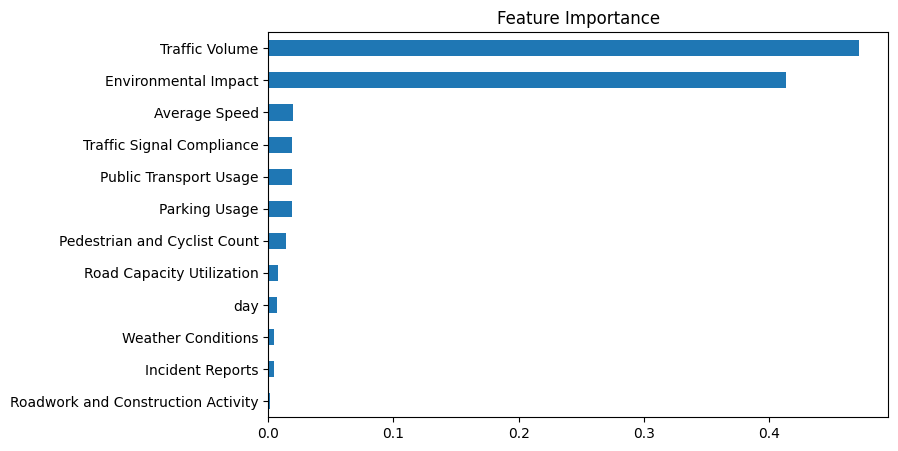

In [13]:
importance = pd.Series(
    time_model.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()

## Save Trained Models

The trained models are saved as `.pkl` files for deployment in the dashboard.

In [14]:
pickle.dump(time_model, open("travel_time_model.pkl","wb"))

pickle.dump(cong_model, open("congestion_model.pkl","wb"))

print("Models saved successfully")

Models saved successfully


## Test Model Prediction

In [15]:
sample = X_test.iloc[0:1]

print("Predicted Travel Time Index:", time_model.predict(sample))

print("Predicted Traffic Class:", cong_model.predict(sample))

Predicted Travel Time Index: [1.5]
Predicted Traffic Class: [2]
